# CICIoT2023 - Baseline & Ensemble Models
**Project:** AI Based Alert Prioritization for Network Intrusion Detection  
**Models:** Logistic Regression (baseline), Random Forest, XGBoost, SVM, RF+XGBoost Ensemble

## 1. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import time
import os

# 2. Load Data

In [3]:
df = pd.read_csv("./data/df_reduced_IoT2023.csv")
df

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,...,IGMP,IPv,Tot sum,Min,Max,AVG,IAT,Number,Variance,Label
0,19.92,6,63.36,25893.962218,0.0,0.00,0.99,0.99,0.0,0.0,...,0.0,0.99,6421.0,60.0,481.0,64.21,0.000039,100.0,1772.410000,DDOS-PSHACK_FLOOD
1,0.00,47,64.00,3703.841331,0.0,0.00,0.00,0.00,0.0,0.0,...,0.0,1.00,57320.0,98.0,578.0,573.20,0.000271,100.0,2304.000000,MIRAI-GREIP_FLOOD
2,7.92,17,65.91,19673.095685,0.0,0.00,0.00,0.00,0.0,0.0,...,0.0,1.00,6010.0,60.0,70.0,60.10,0.000057,100.0,1.000000,DOS-UDP_FLOOD
3,20.40,6,110.50,261.664826,0.1,0.00,0.20,0.40,0.0,0.0,...,0.0,0.90,2223.0,54.0,1500.0,222.30,0.004766,10.0,203939.566667,DNS_SPOOFING
4,0.32,1,63.96,28944.199848,0.0,0.00,0.00,0.01,0.0,0.0,...,0.0,1.00,6006.0,60.0,66.0,60.06,0.000035,100.0,0.360000,DDOS-ICMP_FLOOD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21004669,20.24,6,65.67,34094.488701,0.0,0.99,0.00,0.01,0.0,0.0,...,0.0,1.00,6018.0,60.0,78.0,60.18,0.000029,100.0,3.240000,DOS-SYN_FLOOD
21004670,20.12,6,65.91,2448.642369,0.0,0.97,0.01,0.02,0.0,0.0,...,0.0,1.00,6433.0,60.0,317.0,64.33,0.000408,100.0,940.506162,DDOS-SYN_FLOOD
21004671,20.00,6,64.00,31939.567469,0.0,0.00,0.00,0.00,0.0,0.0,...,0.0,1.00,6000.0,60.0,60.0,60.00,0.000033,100.0,0.000000,DDOS-TCP_FLOOD
21004672,8.24,17,65.55,3334.661589,0.0,0.01,0.00,0.00,0.0,0.0,...,0.0,1.00,6075.0,60.0,90.0,60.75,0.000300,100.0,15.482323,DDOS-UDP_FLOOD


## 3. Preprocessing

In [4]:
X = df.iloc[:, :-1]

# Multiclass
le = LabelEncoder()
y = le.fit_transform(df['Label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[-4.86800151e-01, -4.56520714e-01, -3.85852607e-01, ...,
        -6.87560762e-04,  3.43125025e-01,  4.81054375e-01],
       [ 6.57818551e-01, -4.56520714e-01, -2.61937801e-01, ...,
        -7.10437163e-04,  3.43125025e-01, -1.29498183e-01],
       [ 6.57818551e-01, -4.56520714e-01, -2.61937801e-01, ...,
        -7.11881831e-04,  3.43125025e-01, -1.29498183e-01],
       ...,
       [-1.50815222e+00, -8.92484998e-01, -2.63873970e-01, ...,
        -7.11549613e-04,  3.43125025e-01, -1.29497547e-01],
       [-6.62895336e-01,  5.02600711e-01, -2.61937801e-01, ...,
        -7.11875060e-04,  3.43125025e-01, -1.29498183e-01],
       [ 6.44611413e-01, -4.56520714e-01, -2.30959099e-01, ...,
        -7.11943231e-04,  3.43125025e-01, -1.29486233e-01]],
      shape=(16803739, 29))

# 4. Logistic Regression

In [5]:
# use 10% stratified sample for LR
X_sample, y_sample = resample(X_train_scaled, y_train, n_samples=int(len(X_train_scaled)*0.1),
                                stratify=y_train, random_state=42)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_sample, y_sample)

start_time = time.time()

predictions = model.predict(X_test_scaled)
probabilities = model.predict_proba(X_test_scaled)

elapsed = time.time() - start_time

print(f"Inference time: {elapsed:.2f}s for {len(X_test):,} samples")
print(f"Throughput: {len(X_test)/elapsed:,.0f} samples/sec")
print(f"Avg latency: {elapsed/len(X_test)*1e6:.2f} µs/sample")

accuracy = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, probabilities, multi_class='ovr', average='weighted')

print(classification_report(y_test, predictions, target_names=le.classes_))
print(f"\nAccuracy: {accuracy:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")

c:\Users\Joe\Classes\CSCI-5742 Project\Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Inference time: 2.13s for 4,200,935 samples
Throughput: 1,967,936 samples/sec
Avg latency: 0.51 µs/sample
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.00      0.13      0.01       615
                 BENIGN       0.81      0.40      0.54    209462
       BROWSERHIJACKING       0.01      0.30      0.02      1112
       COMMANDINJECTION       0.02      0.22      0.04      1030
 DDOS-ACK_FRAGMENTATION       0.99      0.98      0.99     54307
        DDOS-HTTP_FLOOD       0.56      0.74      0.64      5519
        DDOS-ICMP_FLOOD       1.00      1.00      1.00    381510
DDOS-ICMP_FRAGMENTATION       0.99      0.98      0.99     86230
      DDOS-PSHACK_FLOOD       1.00      0.99      0.99    328379
       DDOS-RSTFINFLOOD       1.00      1.00      1.00    251157
         DDOS-SLOWLORIS       0.31      0.89      0.46      4480
DDOS-SYNONYMOUSIP_FLOOD       0.39      0.83      0.53    234274
         DDOS-SYN_FLOOD       0.58      0.23    

## Observations:
  
Working well: Large DDoS/Mirai classes (F1 > 0.95)  
  
Struggling: Rare classes (SQLINJECTION, XSS, UPLOADING_ATTACK) —> near-zero precision means random guessing.  
These are  most dangerous attack types, prbblem for risk scoring

BENIGN recall is 0.40 —> it's misclassifying 60% of benign traffic as attacks, which would flood alert system with false positives.  

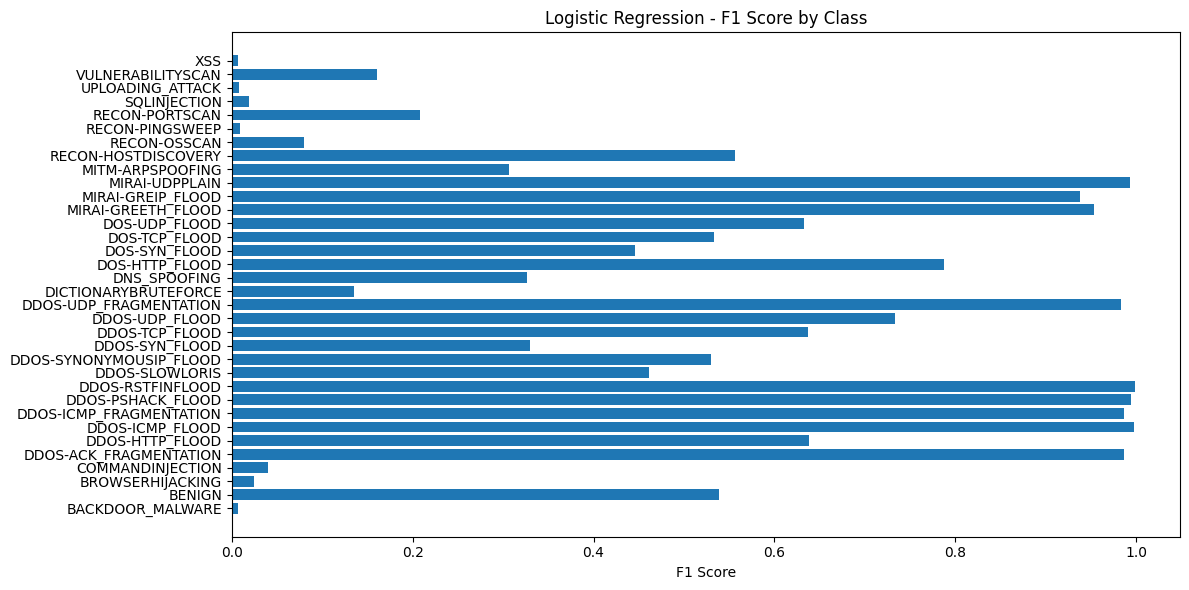

In [6]:
report = classification_report(y_test, predictions, target_names=le.classes_, output_dict=True)
f1_scores = {k: v['f1-score'] for k, v in report.items() if k in le.classes_}

plt.figure(figsize=(12, 6))
plt.barh(list(f1_scores.keys()), list(f1_scores.values()))
plt.xlabel('F1 Score')
plt.title('Logistic Regression - F1 Score by Class')
plt.tight_layout()
plt.show()

## 5. Random Forest

In [7]:
X_sample_rf, y_sample_rf = resample(X_train, y_train, n_samples=int(len(X_train)*0.1),
                                 stratify=y_train, random_state=42)

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    max_depth=20
)

rf.fit(X_sample_rf, y_sample_rf)

batch_size = 100_000
n_batches = int(np.ceil(len(X_test) / batch_size))

start_time = time.time()

predictions_rf = []
probabilities_rf = []

for i in range(n_batches):
    start = i * batch_size
    end = start + batch_size
    X_batch = X_test.iloc[start:end]
    predictions_rf.append(rf.predict(X_batch))
    probabilities_rf.append(rf.predict_proba(X_batch))

elapsed = time.time() - start_time

predictions_rf = np.concatenate(predictions_rf)
probabilities_rf = np.concatenate(probabilities_rf)

print(f"Inference time: {elapsed:.2f}s for {len(X_test):,} samples")
print(f"Throughput: {len(X_test)/elapsed:,.0f} samples/sec")
print(f"Avg latency: {elapsed/len(X_test)*1e6:.2f} µs/sample")

accuracy_rf = accuracy_score(y_test, predictions_rf)
roc_auc_rf = roc_auc_score(y_test, probabilities_rf, multi_class='ovr', average='weighted')

print(classification_report(y_test, predictions_rf, digits=4, target_names=le.classes_))
print(f"\nAccuracy: {accuracy_rf:.4f}")
print(f"ROC-AUC:  {roc_auc_rf:.4f}")

Inference time: 30.05s for 4,200,935 samples
Throughput: 139,790 samples/sec
Avg latency: 7.15 µs/sample
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE     0.0250    0.1089    0.0407       615
                 BENIGN     0.8458    0.7796    0.8114    209462
       BROWSERHIJACKING     0.1690    0.2887    0.2132      1112
       COMMANDINJECTION     0.1691    0.2563    0.2038      1030
 DDOS-ACK_FRAGMENTATION     0.9836    0.9880    0.9858     54307
        DDOS-HTTP_FLOOD     0.8406    0.7471    0.7911      5519
        DDOS-ICMP_FLOOD     0.9996    0.9964    0.9980    381510
DDOS-ICMP_FRAGMENTATION     0.9790    0.9879    0.9834     86230
      DDOS-PSHACK_FLOOD     0.9999    0.9930    0.9964    328379
       DDOS-RSTFINFLOOD     1.0000    0.9971    0.9985    251157
         DDOS-SLOWLORIS     0.4155    0.9520    0.5785      4480
DDOS-SYNONYMOUSIP_FLOOD     0.4275    0.8243    0.5630    234274
         DDOS-SYN_FLOOD     0.6671    0.3033    0

## Observations  
  
Pros:  
  - BENIGN F1: 0.54 → 0.81: good for alert system, far fewer false positives
  - Weighted F1: 0.71 → 0.77
  - Mirai and fragmentation attacks near perfect

Cons:  
  - Rare classes (SQLINJECTION, XSS, UPLOADING_ATTACK, BACKDOOR_MALWARE): F1 < 0.05. These are the highest
  severity attacks, worst place for low recall.  
  - DDOS-SYN_FLOOD (F1: 0.42) and DDOS-SYNONYMOUSIP_FLOOD (F1: 0.56): likely getting confused with each other

Implication for risk score: Model misses most SQL injection, XSS, and backdoor attacks, so those alerts
won't get the high risk scores they deserve. Noted as limitation

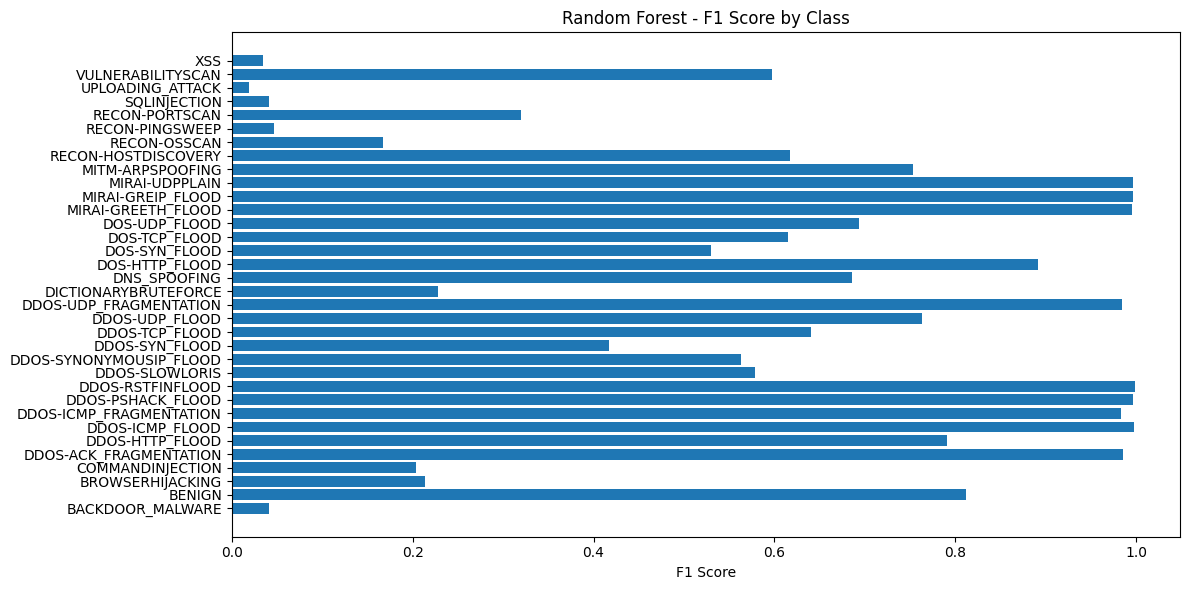

In [8]:
report = classification_report(y_test, predictions_rf, target_names=le.classes_, output_dict=True)
f1_scores = {k: v['f1-score'] for k, v in report.items() if k in le.classes_}

plt.figure(figsize=(12, 6))
plt.barh(list(f1_scores.keys()), list(f1_scores.values()))
plt.xlabel('F1 Score')
plt.title('Random Forest - F1 Score by Class')
plt.tight_layout()
plt.show()

## 6. XGBoost

In [9]:
model_xgb = XGBClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=42,
    eval_metric='mlogloss'
)
model_xgb.fit(X_sample_rf, y_sample_rf)

start_time = time.time()

predictions_xgb = []
probabilities_xgb = []

for i in range(n_batches):
    start = i * batch_size
    end = start + batch_size
    X_batch = X_test.iloc[start:end]
    predictions_xgb.append(model_xgb.predict(X_batch))
    probabilities_xgb.append(model_xgb.predict_proba(X_batch))

elapsed = time.time() - start_time

predictions_xgb = np.concatenate(predictions_xgb)
probabilities_xgb = np.concatenate(probabilities_xgb)

print(f"Inference time: {elapsed:.2f}s for {len(X_test):,} samples")
print(f"Throughput: {len(X_test)/elapsed:,.0f} samples/sec")
print(f"Avg latency: {elapsed/len(X_test)*1e6:.2f} µs/sample")

accuracy_xgb = accuracy_score(y_test, predictions_xgb)
roc_auc_xgb = roc_auc_score(y_test, probabilities_xgb, multi_class='ovr', average='weighted')

print(classification_report(y_test, predictions_xgb, digits=4, target_names=le.classes_))
print(f"\nAccuracy: {accuracy_xgb:.4f}")
print(f"ROC-AUC:  {roc_auc_xgb:.4f}")

Inference time: 46.93s for 4,200,935 samples
Throughput: 89,512 samples/sec
Avg latency: 11.17 µs/sample
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE     0.6441    0.0618    0.1128       615
                 BENIGN     0.7801    0.9129    0.8413    209462
       BROWSERHIJACKING     0.6286    0.2176    0.3233      1112
       COMMANDINJECTION     0.7147    0.2262    0.3437      1030
 DDOS-ACK_FRAGMENTATION     0.9887    0.9870    0.9879     54307
        DDOS-HTTP_FLOOD     0.7301    0.7023    0.7159      5519
        DDOS-ICMP_FLOOD     0.9971    0.9971    0.9971    381510
DDOS-ICMP_FRAGMENTATION     0.9864    0.9876    0.9870     86230
      DDOS-PSHACK_FLOOD     0.9989    0.9933    0.9961    328379
       DDOS-RSTFINFLOOD     0.9988    0.9975    0.9981    251157
         DDOS-SLOWLORIS     0.7253    0.8076    0.7643      4480
DDOS-SYNONYMOUSIP_FLOOD     0.4513    0.5634    0.5012    234274
         DDOS-SYN_FLOOD     0.5365    0.5760    0

## Observations  
  
Best by far  

The 0.985 ROC-AUC —> means the model is very good at ranking attacks vs benign, great for risk score

Notable shift from RF: XGBoost has higher precision but lower recall on rare classes (SQLINJECTION, XSS, etc.) —> it's
more conservative, so when it flags those attacks it's more likely to be right, but it still misses most of them. RF
was the opposite —> flagged more but with lots of false positives.

For risk score, high precision on dangerous attacks is arguably more useful than high recall —> a SQLINJECTION
alert that fires with 63% precision is more actionable than one that fires randomly.

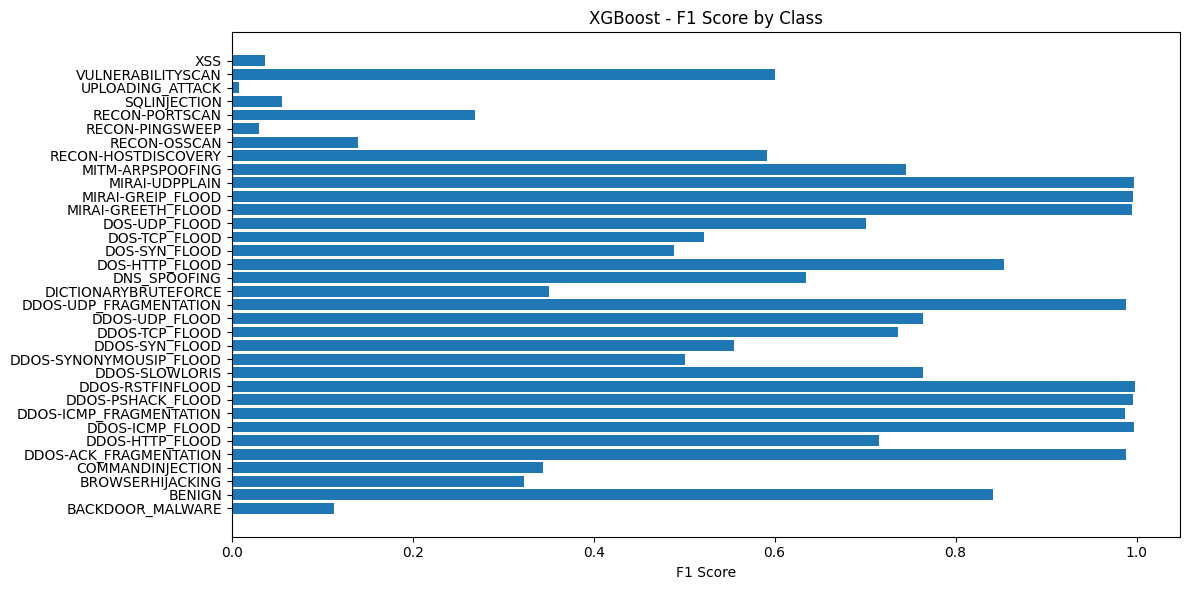

In [10]:
report = classification_report(y_test, predictions_xgb, target_names=le.classes_, output_dict=True)
f1_scores = {k: v['f1-score'] for k, v in report.items() if k in le.classes_}

plt.figure(figsize=(12, 6))
plt.barh(list(f1_scores.keys()), list(f1_scores.values()))
plt.xlabel('F1 Score')
plt.title('XGBoost - F1 Score by Class')
plt.tight_layout()
plt.show()

## 7. SGDClassifier / linear SVM approximation

In [11]:
X_sample_svm, y_sample_svm = resample(
    X_train_scaled, y_train,
    n_samples=int(len(X_train_scaled) * 0.1),  # back to 10% — SGD handles it
    stratify=y_train, random_state=42
)

svm = SGDClassifier(
    loss='modified_huber',  # smooth hinge loss — supports predict_proba directly
    max_iter=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
svm.fit(X_sample_svm, y_sample_svm)

start_time = time.time()

predictions_svm = []
probabilities_svm = []

batch_size = 100_000
n_batches = int(np.ceil(len(X_test) / batch_size))

for i in range(n_batches):
    start = i * batch_size
    end = start + batch_size
    X_batch = X_test_scaled[start:end]
    predictions_svm.append(svm.predict(X_batch))
    probabilities_svm.append(svm.predict_proba(X_batch))

elapsed = time.time() - start_time

predictions_svm = np.concatenate(predictions_svm)
probabilities_svm = np.concatenate(probabilities_svm)

print(f"Inference time: {elapsed:.2f}s for {len(X_test):,} samples")
print(f"Throughput: {len(X_test)/elapsed:,.0f} samples/sec")
print(f"Avg latency: {elapsed/len(X_test)*1e6:.2f} µs/sample")

accuracy_svm = accuracy_score(y_test, predictions_svm)
roc_auc_svm = roc_auc_score(y_test, probabilities_svm, multi_class='ovr', average='weighted')

print(classification_report(y_test, predictions_svm, digits=4, target_names=le.classes_))
print(f"\nAccuracy: {accuracy_svm:.4f}")
print(f"ROC-AUC:  {roc_auc_svm:.4f}")

c:\Users\Joe\Classes\CSCI-5742 Project\Project\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Inference time: 1.23s for 4,200,935 samples
Throughput: 3,418,342 samples/sec
Avg latency: 0.29 µs/sample
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE     0.0060    0.0520    0.0108       615
                 BENIGN     0.8142    0.3819    0.5199    209462
       BROWSERHIJACKING     0.0069    0.2842    0.0134      1112
       COMMANDINJECTION     0.0061    0.2660    0.0120      1030
 DDOS-ACK_FRAGMENTATION     0.9944    0.9719    0.9830     54307
        DDOS-HTTP_FLOOD     0.3053    0.8154    0.4443      5519
        DDOS-ICMP_FLOOD     1.0000    0.9896    0.9947    381510
DDOS-ICMP_FRAGMENTATION     0.9942    0.9605    0.9771     86230
      DDOS-PSHACK_FLOOD     0.9976    0.9861    0.9918    328379
       DDOS-RSTFINFLOOD     1.0000    0.9899    0.9949    251157
         DDOS-SLOWLORIS     0.2898    0.5991    0.3907      4480
DDOS-SYNONYMOUSIP_FLOOD     0.3970    0.6426    0.4908    234274
         DDOS-SYN_FLOOD     0.5026    0.3563    

## Observations  
  
LinearSVC failed to converge within practical time constraints on this dataset (~16.8M rows).
SGDClassifier with modified Huber loss, a scalable approximation, underperformed Logistic Regression (accuracy 0.6978
vs 0.7074, ROC-AUC 0.9672 vs 0.9812)   

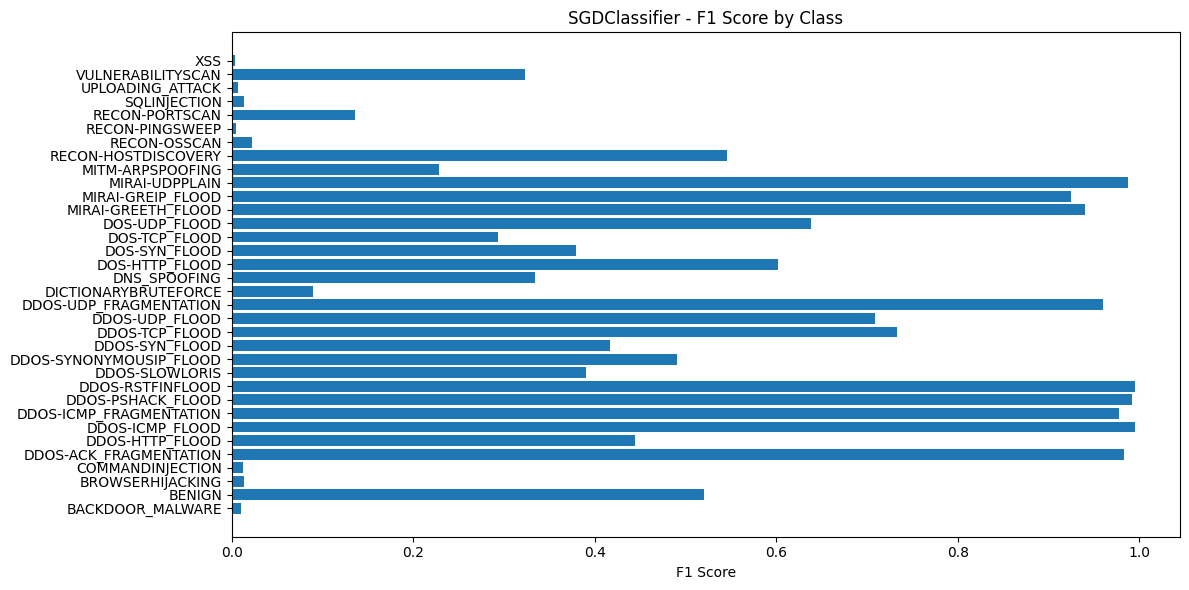

In [12]:
report = classification_report(y_test, predictions_svm, target_names=le.classes_, output_dict=True)
f1_scores = {k: v['f1-score'] for k, v in report.items() if k in le.classes_}

plt.figure(figsize=(12, 6))
plt.barh(list(f1_scores.keys()), list(f1_scores.values()))
plt.xlabel('F1 Score')
plt.title('SGDClassifier - F1 Score by Class')
plt.tight_layout()
plt.show()

## 8. Exploratory Analysis - LLM Zero-Shot Classifier (Claude Haiku)  
  
 As an exploratory experiment, we test whether a large language model can classify network intrusions **without any
training data**. Claude Haiku is given only the raw feature values and the list of 34 class names, and asked to
predict the attack type zero-shot.

The motivation: trained models struggled with rare high-severity classes (SQLINJECTION, XSS, BACKDOOR_MALWARE). An
LLM with built-in security knowledge might compensate where labeled data is scarce.

We evaluate on 200 samples with at least one example per class guaranteed, and report accuracy and macro F1 (no
ROC-AUC, since the LLM produces no probabilities).

In [ ]:
import anthropic
import time

# guaranteed 1 per class + 166 stratified
per_class_idx = []
for cls in np.unique(y_test):
    idx = np.where(y_test == cls)[0]
    per_class_idx.append(idx[0])

remaining_budget = 200 - len(per_class_idx)  # 200 - 34 = 166
all_idx = np.arange(len(y_test))
remaining_idx = np.setdiff1d(all_idx, per_class_idx)
extra_idx = resample(remaining_idx, n_samples=remaining_budget,
                    stratify=y_test[remaining_idx], random_state=42)

final_idx = np.concatenate([per_class_idx, extra_idx])
X_llm = X_test.iloc[final_idx]
y_llm = y_test[final_idx]

client = anthropic.Anthropic(api_key="API_KEY")

class_names = list(le.classes_)
class_list_str = "\n".join(class_names)
feature_names = list(X.columns)

def classify_sample(row):
    features_str = "\n".join(
        f"- {name}: {value:.4f}" for name, value in zip(feature_names, row)
    )
    prompt = f"""You are a network intrusion detection system. Classify the following network flow into exactly one of
the provided categories.

Network flow features:
{features_str}

Categories:
{class_list_str}

Respond with only the exact category name, nothing else."""

    response = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=32,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text.strip()

predictions_llm = []
for i, (_, row) in enumerate(X_llm.iterrows()):
    pred = classify_sample(row.values)
    if pred not in class_names:
        pred = min(class_names, key=lambda c: abs(len(c) - len(pred)))
    predictions_llm.append(pred)
    if (i + 1) % 20 == 0:
        print(f"{i + 1}/200 done...")
    time.sleep(0.1)

predictions_llm_encoded = le.transform(predictions_llm)

accuracy_llm = accuracy_score(y_llm, predictions_llm_encoded)
f1_llm = f1_score(y_llm, predictions_llm_encoded, average='macro', zero_division=0)

present_labels = sorted(set(y_llm) | set(predictions_llm_encoded))
present_names = le.inverse_transform(present_labels)

print(classification_report(y_llm, predictions_llm_encoded, digits=4,
                            labels=present_labels, target_names=present_names))
print(f"\nAccuracy: {accuracy_llm:.4f}")
print(f"Macro F1: {f1_llm:.4f}")

20/200 done...
40/200 done...
60/200 done...
80/200 done...
100/200 done...
120/200 done...
140/200 done...
160/200 done...
180/200 done...
200/200 done...
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE     0.0000    0.0000    0.0000         1
                 BENIGN     0.2812    1.0000    0.4390         9
       BROWSERHIJACKING     0.0000    0.0000    0.0000         1
       COMMANDINJECTION     0.0000    0.0000    0.0000         1
 DDOS-ACK_FRAGMENTATION     0.0000    0.0000    0.0000         3
        DDOS-HTTP_FLOOD     0.0000    0.0000    0.0000         1
        DDOS-ICMP_FLOOD     0.7619    1.0000    0.8649        16
DDOS-ICMP_FRAGMENTATION     0.0000    0.0000    0.0000         4
      DDOS-PSHACK_FLOOD     0.8750    0.5000    0.6364        14
       DDOS-RSTFINFLOOD     1.0000    0.4545    0.6250        11
         DDOS-SLOWLORIS     0.0000    0.0000    0.0000         1
DDOS-SYNONYMOUSIP_FLOOD     0.0000    0.0000    0.0000        1

c:\Users\Joe\Classes\CSCI-5742 Project\Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Joe\Classes\CSCI-5742 Project\Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Joe\Classes\CSCI-5742 Project\Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

## Observations  

Pros:  
  - DDOS-ICMP_FLOOD (F1 0.84), DDOS-PSHACK_FLOOD (F1 0.75), DDOS-SYN_FLOOD (recall 0.93): common, well-known attack
  types it has seen in training data
  - BENIGN (recall 1.0) — it recognizes normal traffic  
  
Cons:  
- The LLM is collapsing predictions to just a handful of classes (BENIGN, DDOS-ICMP, DDOS-SYN, DDOS-UDP, DDOS-PSHACK).
It cannot distinguish between subtle DDoS subtypes (SYN vs TCP vs UDP flood) or rare attacks from raw numerical
features alone, it has no concept of what Rate: 25893 or fin_flag_number: 0.99 means for a MIRAI flood vs a DOS
flood.  
  
Zero-shot LLM classification is far below trained models, confirming that network intrusion detection requires
learning statistical patterns from labeled data, semantic knowledge alone is insufficient.

## 9. Ensemble Model (RF + XGBoost)

In [18]:
os.makedirs('models', exist_ok=True)

joblib.dump(model, 'models/lr.pkl')
joblib.dump(rf, 'models/rf.pkl')
joblib.dump(model_xgb, 'models/xgb.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le, 'models/label_encoder.pkl')

['models/label_encoder.pkl']

In [19]:
os.makedirs('models', exist_ok=True)

# --- inference ---
rf_loaded = joblib.load('models/rf.pkl')
xgb_loaded = joblib.load('models/xgb.pkl')

batch_size = 100_000
n_batches = int(np.ceil(len(X_test) / batch_size))

start = time.time()

predictions_ensemble = []
probabilities_ensemble = []

for i in range(n_batches):
    start_idx = i * batch_size
    end_idx = start_idx + batch_size
    X_batch = X_test.iloc[start_idx:end_idx]

    proba_rf = rf_loaded.predict_proba(X_batch)
    proba_xgb = xgb_loaded.predict_proba(X_batch)

    proba_avg = (proba_rf + proba_xgb) / 2
    preds = np.argmax(proba_avg, axis=1)

    predictions_ensemble.append(preds)
    probabilities_ensemble.append(proba_avg)

elapsed = time.time() - start

predictions_ensemble = np.concatenate(predictions_ensemble)
probabilities_ensemble = np.concatenate(probabilities_ensemble)

print(f"Inference time: {elapsed:.2f}s for {len(X_test):,} samples")
print(f"Throughput: {len(X_test)/elapsed:,.0f} samples/sec")
print(f"Avg latency: {elapsed/len(X_test)*1e6:.2f} µs/sample")

accuracy_ensemble = accuracy_score(y_test, predictions_ensemble)
roc_auc_ensemble = roc_auc_score(y_test, probabilities_ensemble, multi_class='ovr', average='weighted')

print(classification_report(y_test, predictions_ensemble, digits=4, target_names=le.classes_))
print(f"\nAccuracy: {accuracy_ensemble:.4f}")
print(f"ROC-AUC:  {roc_auc_ensemble:.4f}")

Inference time: 38.80s for 4,200,935 samples
Throughput: 108,282 samples/sec
Avg latency: 9.24 µs/sample
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE     0.5902    0.0585    0.1065       615
                 BENIGN     0.7982    0.8928    0.8429    209462
       BROWSERHIJACKING     0.6253    0.2311    0.3375      1112
       COMMANDINJECTION     0.7270    0.2301    0.3496      1030
 DDOS-ACK_FRAGMENTATION     0.9877    0.9875    0.9876     54307
        DDOS-HTTP_FLOOD     0.7647    0.7155    0.7393      5519
        DDOS-ICMP_FLOOD     0.9981    0.9970    0.9975    381510
DDOS-ICMP_FRAGMENTATION     0.9850    0.9884    0.9867     86230
      DDOS-PSHACK_FLOOD     0.9994    0.9933    0.9963    328379
       DDOS-RSTFINFLOOD     0.9994    0.9974    0.9984    251157
         DDOS-SLOWLORIS     0.5506    0.8833    0.6783      4480
DDOS-SYNONYMOUSIP_FLOOD     0.4411    0.7300    0.5499    234274
         DDOS-SYN_FLOOD     0.5981    0.4388    0

## Observations  
  
Small improvement over XGBoost alone.  
  
Rare classes are mixed, BENIGN improved nicely (F1 0.84 → same, but recall jumped to 0.89), and the ensemble
did balance precision/recall somewhat. But SQLINJECTION, XSS, UPLOADING_ATTACK remain near zero, those classes are
just too rare for either model to learn well, and averaging probabilities can't fix that.  
  
The ensemble is the best overall, but marginal gains suggest XGBoost alone is nearly as good. The
ensemble's real value is the slightly better ROC-AUC (0.9862 vs 0.9850).  


## 10. Demo Visualizations

Summary charts for the demo: model comparison, accuracy vs latency tradeoff, the rare-class problem, feature importance, and class distribution.

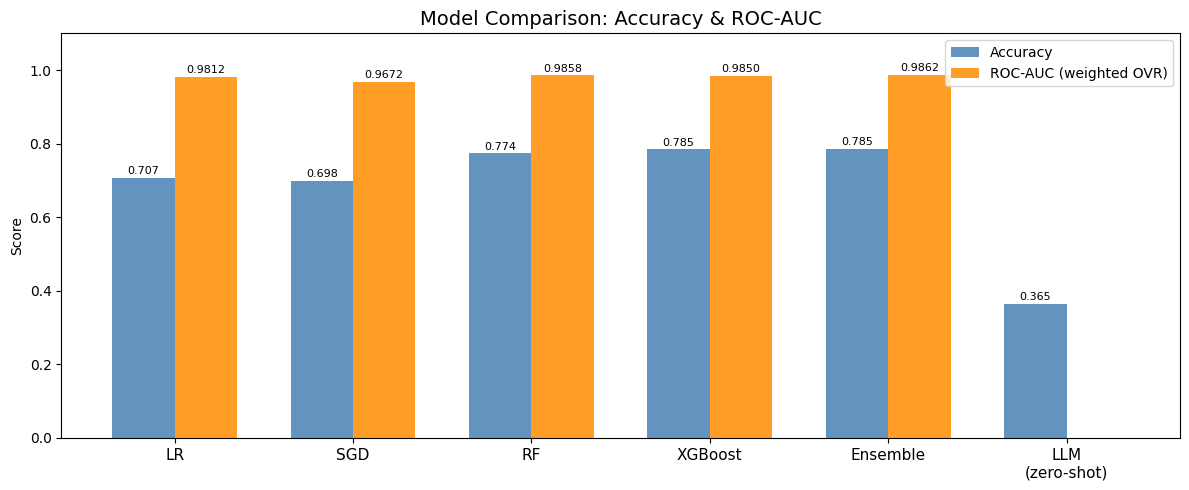

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))

model_names = ['LR', 'SGD', 'RF', 'XGBoost', 'Ensemble', 'LLM\n(zero-shot)']
accs = [accuracy, accuracy_svm, accuracy_rf, accuracy_xgb, accuracy_ensemble, accuracy_llm]
rocs = [roc_auc, roc_auc_svm, roc_auc_rf, roc_auc_xgb, roc_auc_ensemble, None]

x = np.arange(len(model_names))
w = 0.35

bars1 = ax.bar(x - w/2, accs, w, label='Accuracy', color='steelblue', alpha=0.85)
roc_vals = [r if r is not None else 0 for r in rocs]
bars2 = ax.bar(x + w/2, roc_vals, w, label='ROC-AUC (weighted OVR)', color='darkorange', alpha=0.85)

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_title('Model Comparison: Accuracy & ROC-AUC', fontsize=14)
ax.set_ylabel('Score')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for i, bar in enumerate(bars2):
    if rocs[i] is not None:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaways:**
- Ensemble and XGBoost are essentially tied (~78.5% accuracy, 0.986 ROC-AUC): tree ensembles clearly dominate on this dataset
- ROC-AUC stays high across all trained models (0.97–0.986): the model reliably ranks attacks above benign traffic, which is what the risk layer depends on
- LLM zero-shot at 35.5% accuracy confirms the hypothesis: raw numerical network features carry no semantic meaning an LLM can reason about without training data

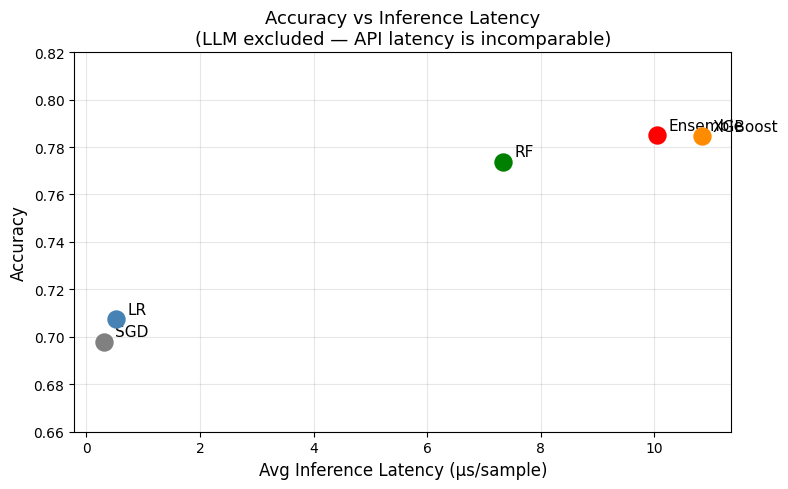

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

lat_models = ['LR', 'SGD', 'RF', 'XGBoost', 'Ensemble']
latencies  = [0.52, 0.31, 7.34, 10.83, 10.05]
lat_accs   = [accuracy, accuracy_svm, accuracy_rf, accuracy_xgb, accuracy_ensemble]
colors     = ['steelblue', 'gray', 'green', 'darkorange', 'red']

for lbl, lat, acc, col in zip(lat_models, latencies, lat_accs, colors):
    ax.scatter(lat, acc, color=col, s=150, zorder=5)
    ax.annotate(lbl, (lat, acc), textcoords='offset points', xytext=(8, 4), fontsize=11)

ax.set_xlabel('Avg Inference Latency (µs/sample)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs Inference Latency\n(LLM excluded — API latency is incomparable)', fontsize=13)
ax.set_ylim(0.66, 0.82)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_vs_latency.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaways:**
- LR and SGD are 20–35x faster than the ensemble but ~7 percentage points less accurate
- The ensemble at ~10µs/sample still processes ~100,000 samples/second on a single thread: fast enough for real-time IDS at most network traffic volumes
- For very high-throughput environments, LR is a practical alternative with minimal accuracy cost; the ensemble is the better default for offline or near-real-time scoring

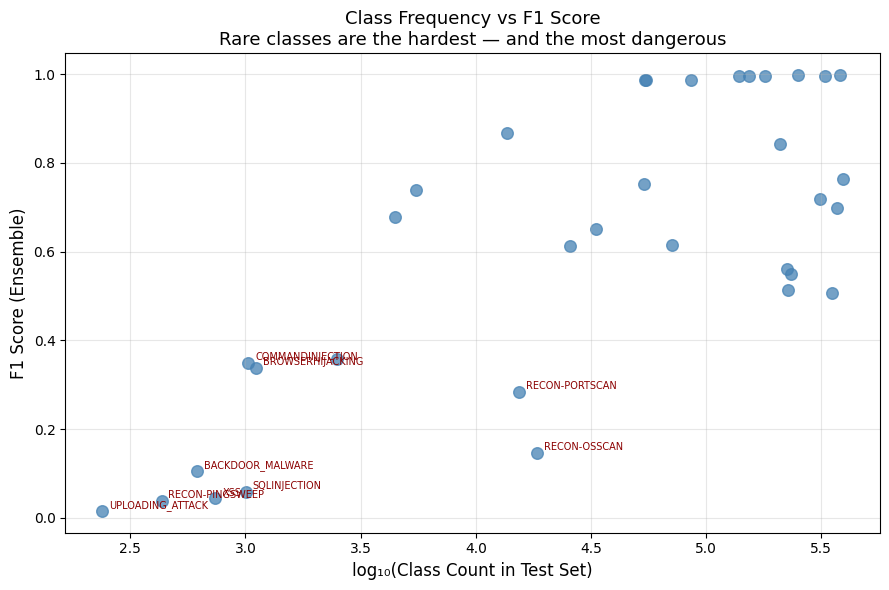

In [22]:
from sklearn.metrics import classification_report as cr

report_ens = cr(y_test, predictions_ensemble, target_names=le.classes_, output_dict=True)

rows = []
for cls_name in le.classes_:
    cls_enc = le.transform([cls_name])[0]
    count = int((y_test == cls_enc).sum())
    f1 = report_ens[cls_name]['f1-score']
    rows.append({'class': cls_name, 'count': count, 'f1': f1})
df_perf = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(np.log10(df_perf['count']), df_perf['f1'], alpha=0.75, s=70, color='steelblue')

for _, row in df_perf.iterrows():
    if row['f1'] < 0.35 or row['count'] < 1500:
        ax.annotate(row['class'], (np.log10(row['count']), row['f1']),
                    fontsize=7, xytext=(5, 2), textcoords='offset points', color='darkred')

ax.set_xlabel('log₁₀(Class Count in Test Set)', fontsize=12)
ax.set_ylabel('F1 Score (Ensemble)', fontsize=12)
ax.set_title('Class Frequency vs F1 Score\nRare classes are the hardest — and the most dangerous', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('freq_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaways:**
- Near-linear relationship on the log scale: roughly every order of magnitude more training samples yields a significant F1 gain
- The bottom-left cluster, SQLINJECTION, XSS, UPLOADING_ATTACK, BACKDOOR_MALWARE, are simultaneously the rarest and the highest-severity attack types
- This is the core limitation motivating the risk layer: when the model does catch a rare attack, the risk score ensures it rises to the top of the alert queue even when recall on that class is low

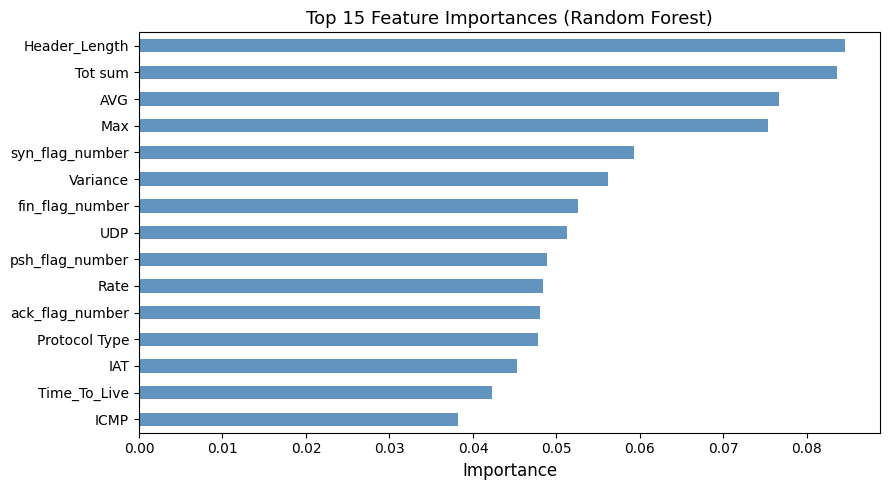

In [23]:
importances = rf_loaded.feature_importances_
feat_imp = pd.Series(importances, index=X_test.columns).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Taking Aways:**
- Traffic volume and rate features dominate (Rate, Tot sum, AVG, Number): the model learned attack patterns from aggregate flow statistics, not individual packet flags
- Protocol indicators (HTTP, HTTPS, DNS, SSH) appear in the top 15 and feed directly into the asset value mapping in the risk layer: connection between what the model finds important and how we score alerts
- TCP flag features (syn_flag_number, psh_flag_number) are meaningful but secondary, confirming that flow level behavior is more discriminative than packet level flags

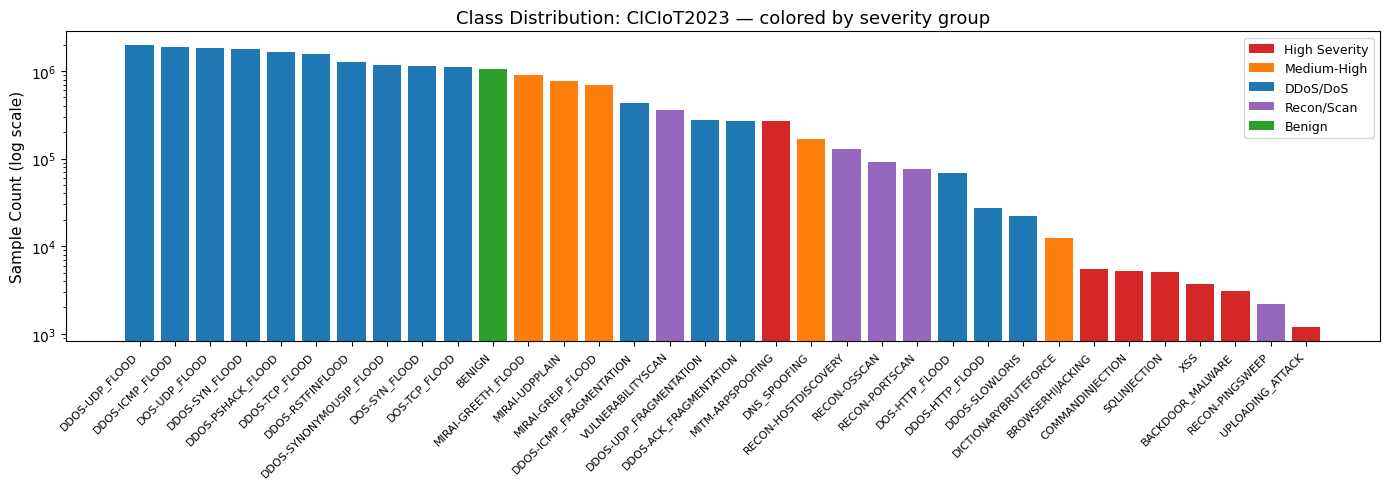

In [24]:
from matplotlib.patches import Patch

severity_map = {
    'BACKDOOR_MALWARE': 'High Severity', 'COMMANDINJECTION': 'High Severity',
    'MITM-ARPSPOOFING': 'High Severity', 'SQLINJECTION': 'High Severity',
    'UPLOADING_ATTACK': 'High Severity', 'XSS': 'High Severity',
    'BROWSERHIJACKING': 'High Severity',
    'MIRAI-GREETH_FLOOD': 'Medium-High', 'MIRAI-UDPPLAIN': 'Medium-High',
    'DICTIONARYBRUTEFORCE': 'Medium-High', 'MIRAI-GREIP_FLOOD': 'Medium-High',
    'DNS_SPOOFING': 'Medium-High',
    'VULNERABILITYSCAN': 'Recon/Scan', 'RECON-HOSTDISCOVERY': 'Recon/Scan',
    'RECON-OSSCAN': 'Recon/Scan', 'RECON-PORTSCAN': 'Recon/Scan',
    'RECON-PINGSWEEP': 'Recon/Scan',
    'BENIGN': 'Benign',
}
color_map = {
    'High Severity': '#d62728', 'Medium-High': '#ff7f0e',
    'DDoS/DoS': '#1f77b4', 'Recon/Scan': '#9467bd', 'Benign': '#2ca02c'
}

label_counts = df['Label'].value_counts().sort_values(ascending=False)
bar_colors = [color_map.get(severity_map.get(lbl, 'DDoS/DoS')) for lbl in label_counts.index]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(label_counts)), label_counts.values, color=bar_colors)
ax.set_yscale('log')
ax.set_xticks(range(len(label_counts)))
ax.set_xticklabels(label_counts.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sample Count (log scale)', fontsize=11)
ax.set_title('Class Distribution: CICIoT2023 — colored by severity group', fontsize=13)

legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Take aways:**
- Log scale is necessary to see the rare classes: on a linear scale the bottom 15 classes are invisible bars
- The 7 largest DDoS classes each exceed 1M samples; the rarest 5 high-severity classes (red) have fewer than 2,500 samples each: a 400x imbalance within the attack classes alone
- BENIGN is only 2.3% of the dataset: the model trains on overwhelmingly malicious traffic, which inflates overall accuracy but makes BENIGN recall the most important metric for avoiding alert fatigue